# Prédiction du prix des logements Airbnb

Ce projet a pour objectif de prédire le logarithme du prix de location d’un logement Airbnb à partir d’un ensemble de caractéristiques (type de logement, équipements, localisation, etc.). 
Nous allons explorer les données, effectuer des traitements de préprocessing, et tester plusieurs modèles de machine learning.


In [111]:
## 1. Chargement des données
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.model_selection   import train_test_split, GridSearchCV
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import StandardScaler, OneHotEncoder
from sklearn.ensemble          import RandomForestRegressor
from sklearn.pipeline          import Pipeline
from sklearn.metrics           import mean_squared_error, r2_score
from xgboost                   import XGBRegressor
from sklearn.ensemble          import GradientBoostingRegressor



# Remplacez par le chemin correct vers votre CSV
data = pd.read_csv('airbnb_train.csv')


## Exploration des données

Nous allons analyser la distribution des prix, identifier les valeurs manquantes, observer la répartition géographique, et étudier la corrélation entre variables.


In [112]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22234 entries, 0 to 22233
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      22234 non-null  int64  
 1   log_price               22234 non-null  float64
 2   property_type           22234 non-null  object 
 3   room_type               22234 non-null  object 
 4   amenities               22234 non-null  object 
 5   accommodates            22234 non-null  int64  
 6   bathrooms               22183 non-null  float64
 7   bed_type                22234 non-null  object 
 8   cancellation_policy     22234 non-null  object 
 9   cleaning_fee            22234 non-null  bool   
 10  city                    22234 non-null  object 
 11  description             22234 non-null  object 
 12  first_review            17509 non-null  object 
 13  host_has_profile_pic    22178 non-null  object 
 14  host_identity_verified  22178 non-null

In [113]:
# Si on a déjà une colonne log_price, on en déduit price ; sinon l’inverse
if 'log_price' in data.columns:
    data['price']     = np.expm1(data['log_price'])
else:
    data['log_price'] = np.log1p(data['price'])


In [114]:
print(f"Forme du DataFrame : {data.shape}")
print("\nValeurs manquantes par colonne :")
print(data.isnull().sum())
print("\nTypes de données :")
print(data.dtypes)

Forme du DataFrame : (22234, 29)

Valeurs manquantes par colonne :
id                           0
log_price                    0
property_type                0
room_type                    0
amenities                    0
accommodates                 0
bathrooms                   51
bed_type                     0
cancellation_policy          0
cleaning_fee                 0
city                         0
description                  0
first_review              4725
host_has_profile_pic        56
host_identity_verified      56
host_response_rate        5475
host_since                  56
instant_bookable             0
last_review               4716
latitude                     0
longitude                    0
name                         0
neighbourhood             2086
number_of_reviews            0
review_scores_rating      4978
zipcode                    303
bedrooms                    26
beds                        35
price                        0
dtype: int64

Types de données :
i

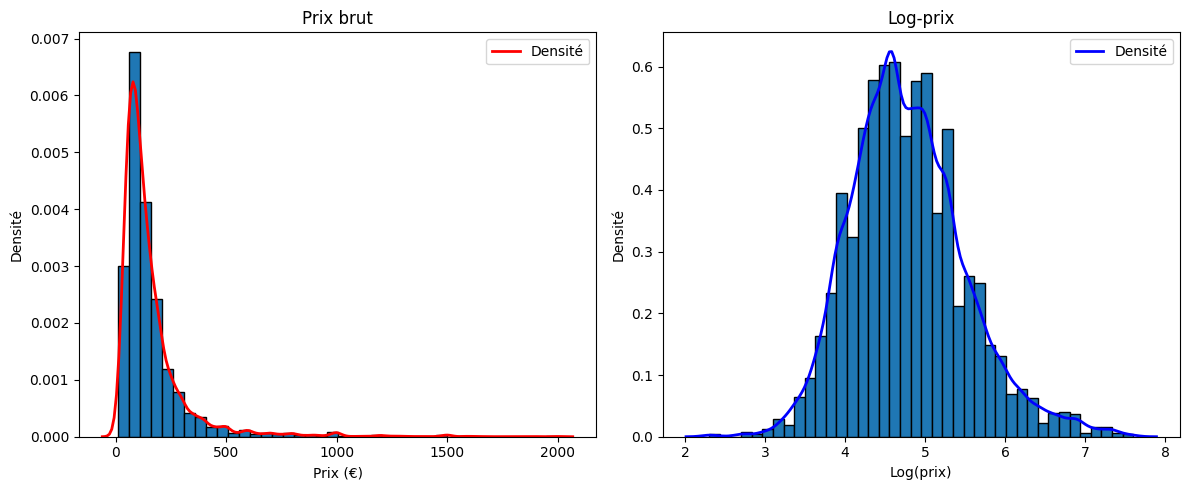

In [115]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(data['price'].dropna(), bins=40, density=True, edgecolor='black')
sns.kdeplot(data['price'].dropna(), color='red', lw=2, label='Densité')
plt.title('Prix brut')
plt.xlabel('Prix (€)')
plt.ylabel('Densité')
plt.legend()

plt.subplot(1,2,2)
plt.hist(data['log_price'].dropna(), bins=40, density=True, edgecolor='black')
sns.kdeplot(data['log_price'].dropna(), color='blue', lw=2, label='Densité')
plt.title('Log-prix')
plt.xlabel('Log(prix)')
plt.ylabel('Densité')
plt.legend()

plt.tight_layout()
plt.show()


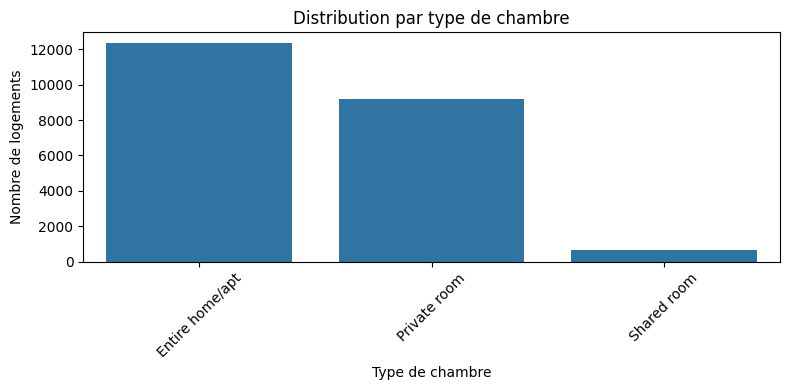

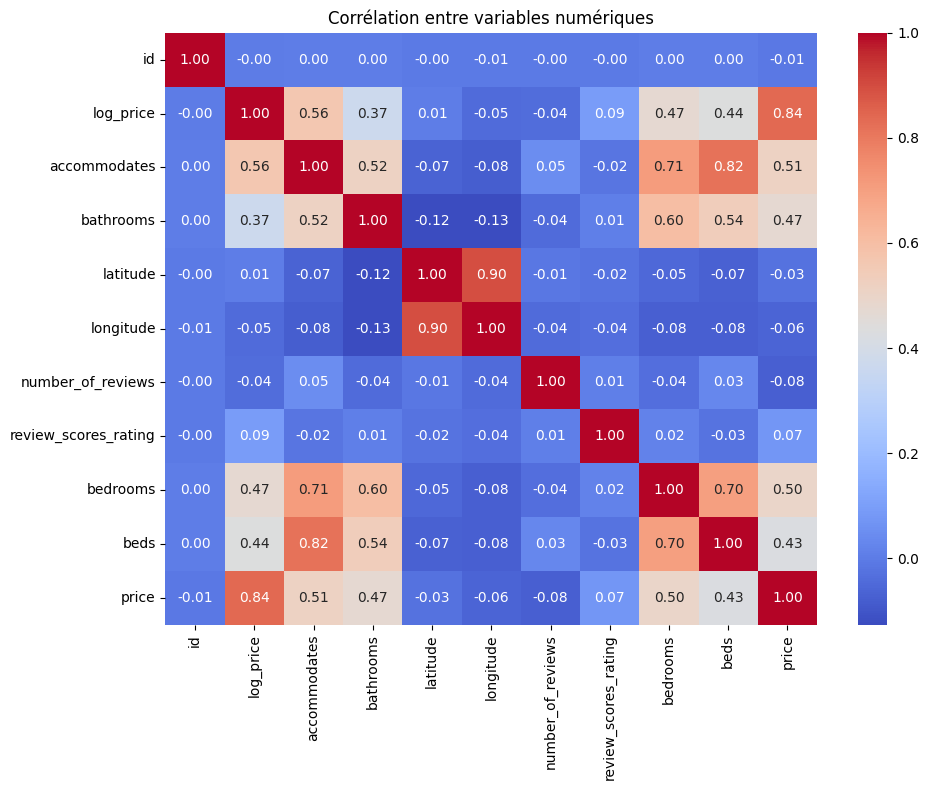

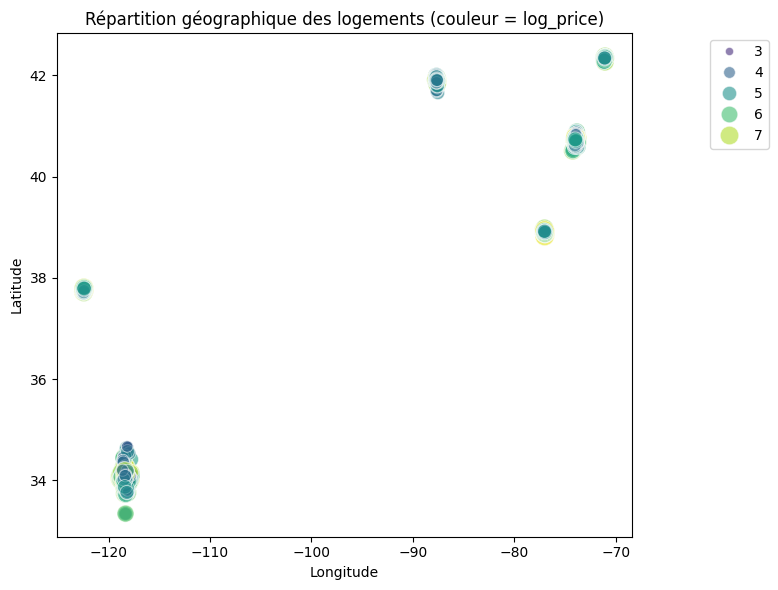

In [116]:
# Chargement des données
train_df = pd.read_csv("airbnb_train.csv")
if "log_price" not in data.columns:
    data["log_price"] = np.log1p(data["price"])

# 1. Répartition des logements par type de chambre
plt.figure(figsize=(8, 4))
sns.countplot(
    data=data,
    x="room_type",
    order=data["room_type"].value_counts().index
)
plt.title("Distribution par type de chambre")
plt.xlabel("Type de chambre")
plt.ylabel("Nombre de logements")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Carte de corrélation entre les variables numériques
num_cols = data.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(
    data[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Corrélation entre variables numériques")
plt.tight_layout()
plt.show()

# 3. Répartition géographique des logements colorée par log_price
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=data,
    x="longitude",
    y="latitude",
    hue="log_price",
    palette="viridis",
    size="log_price",
    sizes=(10, 200),
    alpha=0.6
)
plt.title("Répartition géographique des logements (couleur = log_price)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()


In [117]:
# Nettoyage manuel et split
amen_raw = (
    data['amenities']
        .fillna('[]')
        .str.replace(r'[\{\}"]', '', regex=True)
        .str.split(',')
        .apply(lambda lst: [x.strip() for x in lst if x.strip()])
)

# Liste plate de tous les items, sélection du top25
all_items = pd.Series([item for sub in amen_raw for item in sub])
top25      = all_items.value_counts().head(25).index.tolist()

# Encodage binaire
for amen in top25:
    col = f"has_{amen.replace(' ', '_')}"
    data[col] = amen_raw.apply(lambda lst: int(amen in lst))


In [118]:
city_counts = data['city'].value_counts()
rare       = city_counts[city_counts < 75].index
data['city_cat'] = data['city'].where(~data['city'].isin(rare), 'Other')


In [119]:
data['price_per_guest']    = data['price'] / data['accommodates']
data['beds_per_bedroom']   = data['beds']  / (data['bedrooms'] + 1e-6)
data['bath_per_bed_ratio'] = data['bathrooms'] / (data['beds'] + 1e-6)


In [120]:
# 8. Clustering géographique (KMeans avec 5 clusters)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

coords = data[['latitude', 'longitude']].dropna()
coords_norm = StandardScaler().fit_transform(coords)

kmeans = KMeans(n_clusters=5, random_state=42).fit(coords_norm)

# Créez une colonne 'geo_group' avec des NaN
data['geo_group'] = np.nan

# Utilisez `.iloc` pour assigner les labels en fonction de la position
data.loc[coords.index, 'geo_group'] = pd.Series(kmeans.labels_, index=coords.index)



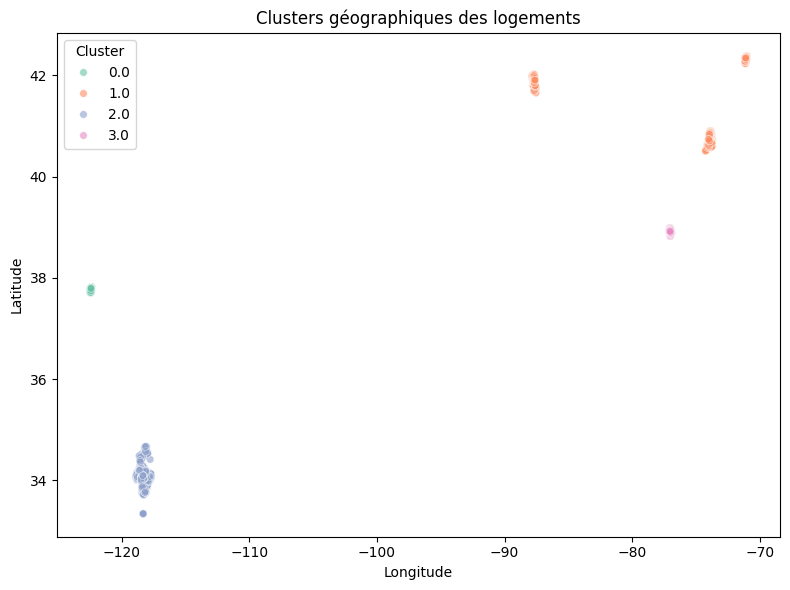

🏙️ Top 3 villes par cluster :

Cluster 0 :
city
SF    1924
Name: count, dtype: int64

Cluster 1 :
city
NYC        9739
Chicago    1127
Boston     1028
Name: count, dtype: int64

Cluster 2 :
city
LA    6672
Name: count, dtype: int64

Cluster 3 :
city
DC    1744
Name: count, dtype: int64


C:\Users\aurel\AppData\Local\Temp\ipykernel_8892\558929499.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\aurel\AppData\Local\Temp\ipykernel_8892\558929499.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


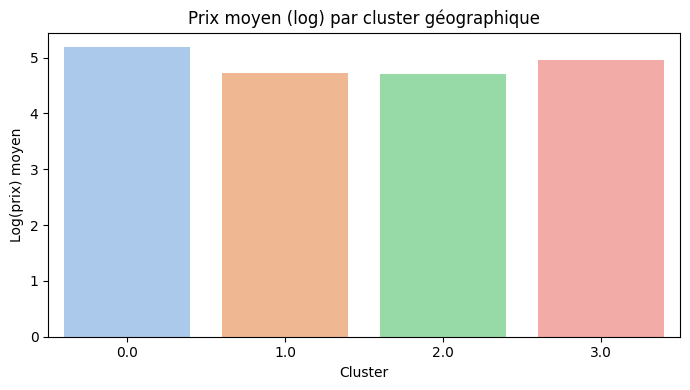

In [121]:
# Clustering géographique si latitude/longitude/city disponibles
if {'latitude', 'longitude', 'city', 'log_price'}.issubset(data.columns):

    # Normalisation et clustering
    coords = data[['latitude', 'longitude']].dropna()
    scaler = StandardScaler()
    coords_scaled = scaler.fit_transform(coords)
    kmeans = KMeans(n_clusters=4, random_state=42)
    clusters = kmeans.fit_predict(coords_scaled)

    # Ajout au DataFrame
    data['geo_cluster'] = np.nan
    data.loc[coords.index, 'geo_cluster'] = clusters

    # Visualisation géographique
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x='longitude', y='latitude', hue='geo_cluster',
        data=data, palette='Set2', alpha=0.6, s=30
    )
    plt.title("Clusters géographiques des logements")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

    # Villes les plus fréquentes par cluster
    print("🏙️ Top 3 villes par cluster :")
    for cid in sorted(data['geo_cluster'].dropna().unique()):
        top_cities = data[data['geo_cluster'] == cid]['city'].value_counts().head(3)
        print(f"\nCluster {int(cid)} :")
        print(top_cities)

    # Prix moyen par cluster
    plt.figure(figsize=(7,4))
    sns.barplot(
        x='geo_cluster',
        y='log_price',
        data=data,
        estimator=np.mean,
        ci=None,
        palette='pastel'
    )
    plt.title("Prix moyen (log) par cluster géographique")
    plt.xlabel("Cluster")
    plt.ylabel("Log(prix) moyen")
    plt.tight_layout()
    plt.show()

else:
    print("Colonnes requises manquantes pour analyse géographique.")


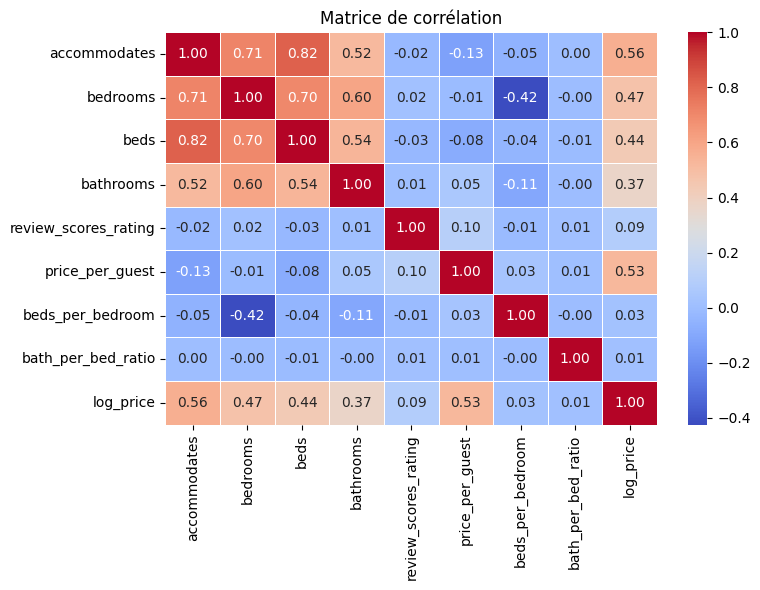

In [122]:
features = [
    'accommodates','bedrooms','beds','bathrooms','review_scores_rating',
    'price_per_guest','beds_per_bedroom','bath_per_bed_ratio','log_price'
]
corr_matrix = data[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,        # affiche les valeurs dans chaque case
    fmt=".2f",         # format des nombres
    cmap="coolwarm",   # palette de couleurs
    linewidths=0.5     # séparation entre les cases
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()


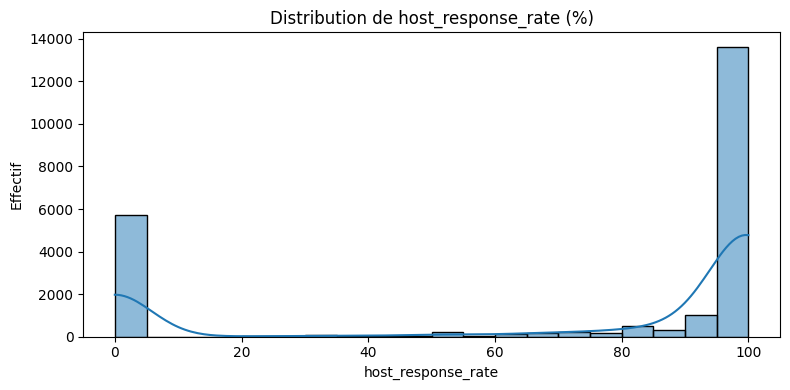

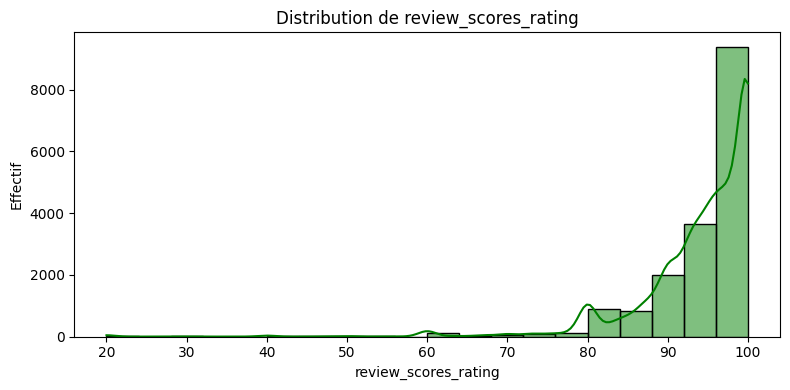

C:\Users\aurel\AppData\Local\Temp\ipykernel_8892\1836974694.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="bed_type", y="log_price", data=data, palette="pastel")


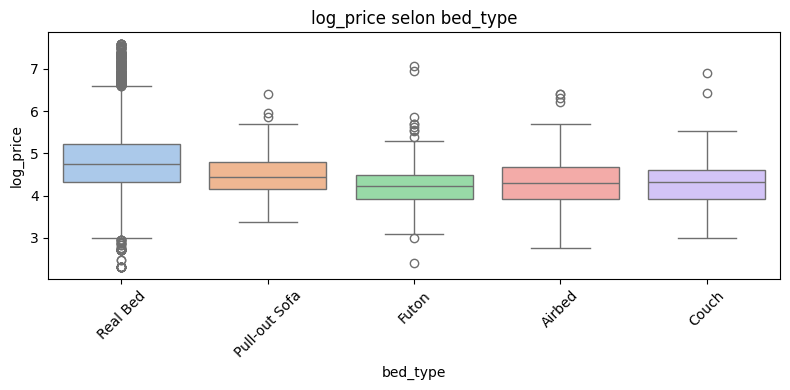

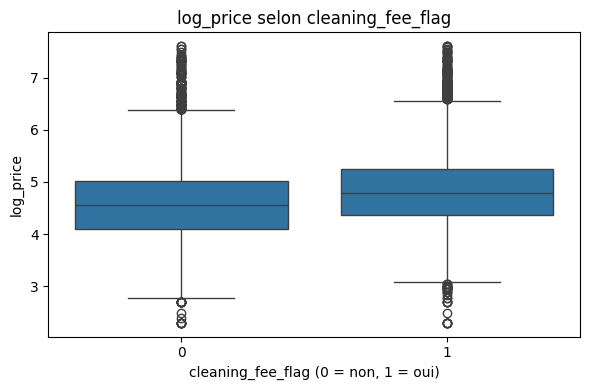

C:\Users\aurel\AppData\Local\Temp\ipykernel_8892\1836974694.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


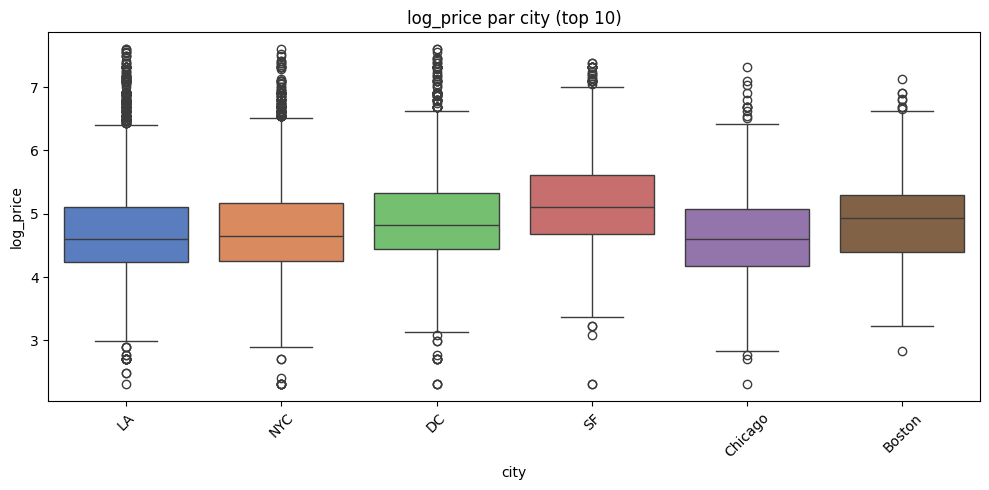

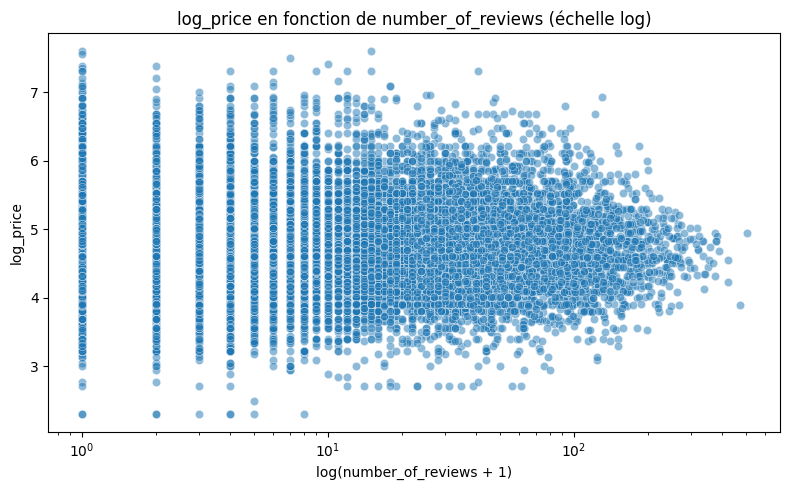

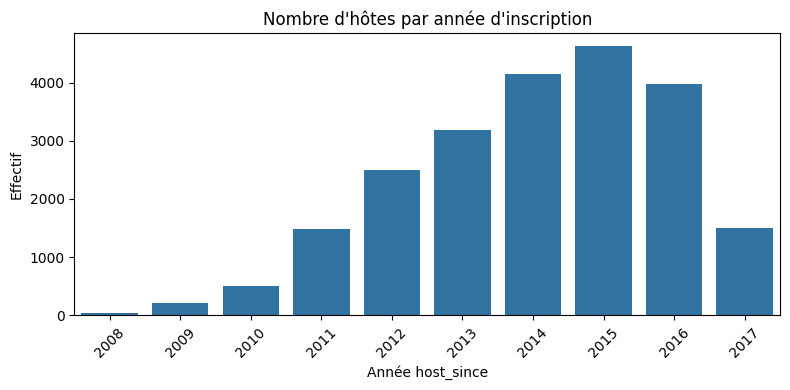

In [123]:
# 1. Histogramme du taux de réponse de l’hôte
plt.figure(figsize=(8, 4))
# On retire les % et on convertit en float
data["host_response_rate"] = data["host_response_rate"].str.rstrip('%').astype(float).fillna(0)
sns.histplot(data["host_response_rate"], bins=20, kde=True)
plt.title("Distribution de host_response_rate (%)")
plt.xlabel("host_response_rate")
plt.ylabel("Effectif")
plt.tight_layout()
plt.show()

# 2. Distribution des notes d'avis
plt.figure(figsize=(8, 4))
sns.histplot(data["review_scores_rating"].dropna(), bins=20, kde=True, color="green")
plt.title("Distribution de review_scores_rating")
plt.xlabel("review_scores_rating")
plt.ylabel("Effectif")
plt.tight_layout()
plt.show()

# 3. Boxplot de log_price par type de lit (bed_type)
plt.figure(figsize=(8, 4))
sns.boxplot(x="bed_type", y="log_price", data=data, palette="pastel")
plt.title("log_price selon bed_type")
plt.xlabel("bed_type")
plt.ylabel("log_price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Boxplot de log_price selon cleaning_fee (présence ou non d’un frais de ménage)
data["cleaning_fee_flag"] = (data["cleaning_fee"] > 0).astype(int)
plt.figure(figsize=(6, 4))
sns.boxplot(x="cleaning_fee_flag", y="log_price", data=data)
plt.title("log_price selon cleaning_fee_flag")
plt.xlabel("cleaning_fee_flag (0 = non, 1 = oui)")
plt.ylabel("log_price")
plt.tight_layout()
plt.show()

# 5. Boxplot de log_price pour les 10 villes les plus fréquentes
top_cities = data["city"].value_counts().head(10).index
plt.figure(figsize=(10, 5))
sns.boxplot(
    x="city", 
    y="log_price", 
    data=data[data["city"].isin(top_cities)], 
    palette="muted"
)
plt.title("log_price par city (top 10)")
plt.xlabel("city")
plt.ylabel("log_price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Scatter plot : nombre de reviews vs log_price (avec échelle log pour number_of_reviews)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="number_of_reviews", 
    y="log_price", 
    data=data, 
    alpha=0.5
)
plt.xscale("log")
plt.title("log_price en fonction de number_of_reviews (échelle log)")
plt.xlabel("log(number_of_reviews + 1)")
plt.ylabel("log_price")
plt.tight_layout()
plt.show()

# 7. Histogramme des années depuis la création de l’hôte (host_since)
data["host_since"] = pd.to_datetime(data["host_since"], errors="coerce")
plt.figure(figsize=(8, 4))
sns.countplot(x=data["host_since"].dt.year.dropna().astype(int))
plt.title("Nombre d'hôtes par année d'inscription")
plt.xlabel("Année host_since")
plt.ylabel("Effectif")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


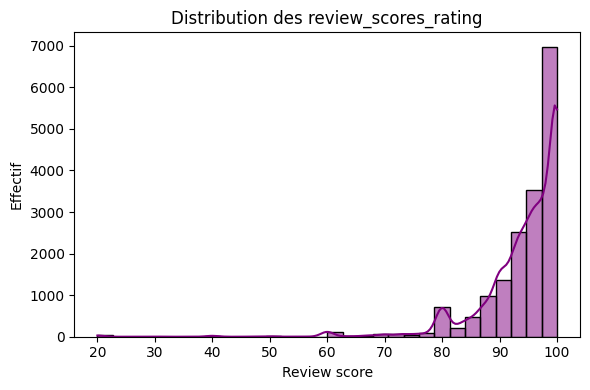

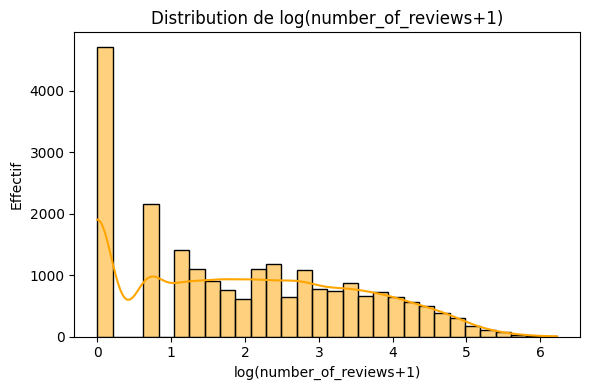

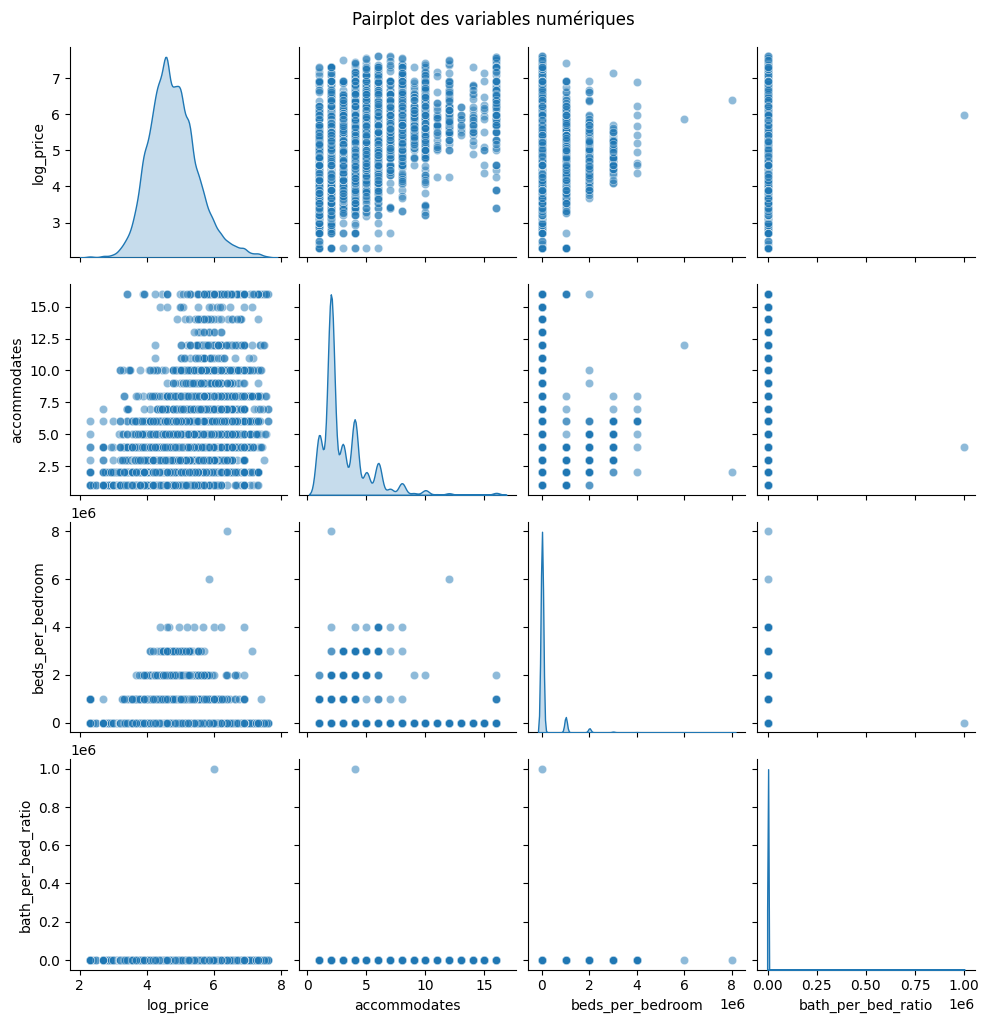

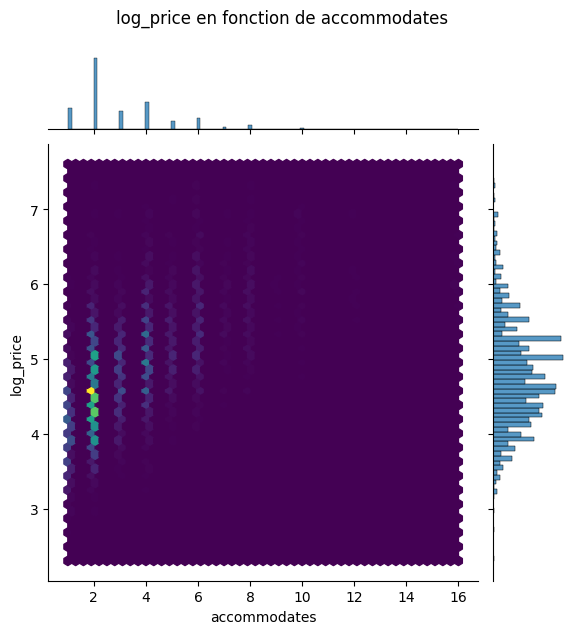

C:\Users\aurel\AppData\Local\Temp\ipykernel_8892\1650444371.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


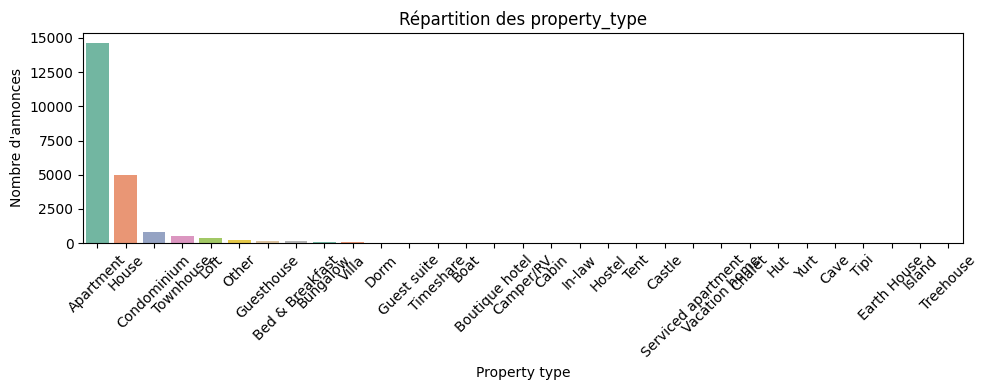

C:\Users\aurel\AppData\Local\Temp\ipykernel_8892\1650444371.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


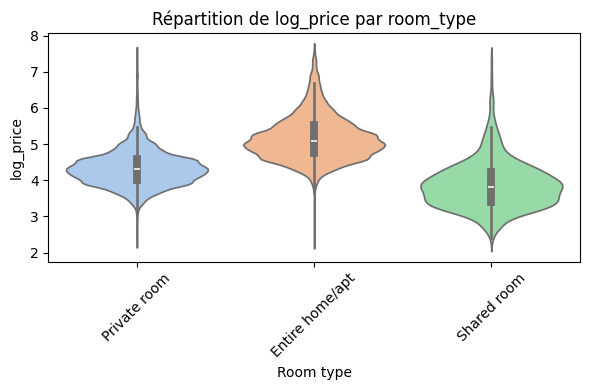

In [124]:

# 1. Histogramme + KDE de la note des avis
plt.figure(figsize=(6,4))
sns.histplot(data['review_scores_rating'].dropna(),
             bins=30, kde=True, color='purple')
plt.title("Distribution des review_scores_rating")
plt.xlabel("Review score")
plt.ylabel("Effectif")
plt.tight_layout()
plt.show()

# 2. Distribution du nombre de reviews (log-échelle)
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(data['number_of_reviews']),
             bins=30, kde=True, color='orange')
plt.title("Distribution de log(number_of_reviews+1)")
plt.xlabel("log(number_of_reviews+1)")
plt.ylabel("Effectif")
plt.tight_layout()
plt.show()

# 3. Pairplot de quelques variables numériques clés
sns.pairplot(
    data[['log_price','accommodates','beds_per_bedroom','bath_per_bed_ratio']].dropna(),
    diag_kind='kde',
    plot_kws={'alpha':0.5}
)
plt.suptitle("Pairplot des variables numériques", y=1.02)
plt.show()

# 4. Jointplot log_price vs accommodates
sns.jointplot(
    data=data,
    x='accommodates', y='log_price',
    kind='hex',
    height=6,
    cmap='viridis'
)
plt.suptitle("log_price en fonction de accommodates", y=1.05)
plt.show()

# 5. Compte des property_type
plt.figure(figsize=(10,4))
sns.countplot(
    data=data,
    x='property_type',
    order=data['property_type'].value_counts().index,
    palette='Set2'
)
plt.title("Répartition des property_type")
plt.xlabel("Property type")
plt.ylabel("Nombre d'annonces")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Violinplot de log_price par room_type
plt.figure(figsize=(6,4))
sns.violinplot(
    data=data,
    x='room_type', y='log_price',
    palette='pastel'
)
plt.title("Répartition de log_price par room_type")
plt.xlabel("Room type")
plt.ylabel("log_price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [125]:
print("Colonnes utilisées dans le DataFrame final :")
for col in data.columns:
    print("-", col)


Colonnes utilisées dans le DataFrame final :
- id
- log_price
- property_type
- room_type
- amenities
- accommodates
- bathrooms
- bed_type
- cancellation_policy
- cleaning_fee
- city
- description
- first_review
- host_has_profile_pic
- host_identity_verified
- host_response_rate
- host_since
- instant_bookable
- last_review
- latitude
- longitude
- name
- neighbourhood
- number_of_reviews
- review_scores_rating
- zipcode
- bedrooms
- beds
- price
- has_Wireless_Internet
- has_Kitchen
- has_Heating
- has_Essentials
- has_Smoke_detector
- has_Air_conditioning
- has_TV
- has_Shampoo
- has_Hangers
- has_Carbon_monoxide_detector
- has_Internet
- has_Laptop_friendly_workspace
- has_Washer
- has_Hair_dryer
- has_Dryer
- has_Iron
- has_Family/kid_friendly
- has_Fire_extinguisher
- has_First_aid_kit
- has_translation_missing:_en.hosting_amenity_50
- has_Cable_TV
- has_Free_parking_on_premises
- has_translation_missing:_en.hosting_amenity_49
- has_24-hour_check-in
- has_Lock_on_bedroom_door
- 

In [90]:
# 12. Sauvegarde du DataFrame traité
data_processed = data.copy()
print("DataFrame traité stocké dans la variable 'data_processed'")

DataFrame traité stocké dans la variable 'data_processed'


# MACHINE LEARNING
On passe maintenant à l'entrainement du modèle de machine learning

In [139]:
data_processed.columns.tolist()
df = data_processed.copy()
df.drop(columns=['price','price_per_guest'], inplace=True)
df.columns.tolist()

['id',
 'log_price',
 'property_type',
 'room_type',
 'amenities',
 'accommodates',
 'bathrooms',
 'bed_type',
 'cancellation_policy',
 'cleaning_fee',
 'city',
 'description',
 'first_review',
 'host_has_profile_pic',
 'host_identity_verified',
 'host_response_rate',
 'host_since',
 'instant_bookable',
 'last_review',
 'latitude',
 'longitude',
 'name',
 'neighbourhood',
 'number_of_reviews',
 'review_scores_rating',
 'zipcode',
 'bedrooms',
 'beds',
 'has_Wireless_Internet',
 'has_Kitchen',
 'has_Heating',
 'has_Essentials',
 'has_Smoke_detector',
 'has_Air_conditioning',
 'has_TV',
 'has_Shampoo',
 'has_Hangers',
 'has_Carbon_monoxide_detector',
 'has_Internet',
 'has_Laptop_friendly_workspace',
 'has_Washer',
 'has_Hair_dryer',
 'has_Dryer',
 'has_Iron',
 'has_Family/kid_friendly',
 'has_Fire_extinguisher',
 'has_First_aid_kit',
 'has_translation_missing:_en.hosting_amenity_50',
 'has_Cable_TV',
 'has_Free_parking_on_premises',
 'has_translation_missing:_en.hosting_amenity_49',
 'h

In [140]:
# Cible
y = df['log_price']

# Caractéristiques numériques 
num_feats = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'review_scores_rating',     
    'beds_per_bedroom', 'bath_per_bed_ratio',        
    'latitude', 'longitude'
]


# Catégorielles
cat_feats = ['city_cat', 'room_type', 'property_type', 'geo_group']

# Amenities (toutes les colonnes commençant par 'has_')
amen_feats = [c for c in df.columns if c.startswith('has_')]

X = df[num_feats + cat_feats + amen_feats]


In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# On commence par établir notre pipline

In [142]:
# Prétraitements
preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), num_feats),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feats)
], remainder='passthrough')  # amenities passent tels quels

# Pipeline complet
pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestRegressor(random_state=0))
])


In [145]:
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth'   : [10, 20, None]
}

grid = GridSearchCV(
    pipeline, param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=1
)

grid.fit(X_train, y_train)
print("Meilleurs paramètres :", grid.best_params_)
print("RMSE CV (grid)      :", -grid.best_score_)


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Meilleurs paramètres : {'rf__max_depth': 20, 'rf__n_estimators': 200}
RMSE CV (grid)      : 0.41070662565843513


In [146]:
best_model = grid.best_estimator_
y_pred     = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test   = r2_score(y_test, y_pred)

print(f"RMSE test : {rmse_test:.3f}")
print(f"R² test   : {r2_test:.3f}")


RMSE test : 0.410
R² test   : 0.671


In [147]:
# Pipeline XGBoost
pipeline_xgb = Pipeline([
    ('prep', preprocessor),
    ('xgb', XGBRegressor(
        random_state=0,
        use_label_encoder=False,
        eval_metric='rmse'
    ))
])

pipeline_gb = Pipeline([
    ('prep', preprocessor),
    ('gb', GradientBoostingRegressor(random_state=0))
])


param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth'   : [3, 6],
    'xgb__learning_rate': [0.1, 0.05]
}

grid = GridSearchCV(
    pipeline_xgb,
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=1
)
grid.fit(X_train, y_train)


# Évaluation XGB sur le test set
y_pred_xgb    = grid.best_estimator_.predict(X_test)
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_test_xgb   = r2_score(y_test, y_pred_xgb)


# Comparaison avec Random Forest
y_pred_rf    = best_model.predict(X_test)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_test_rf   = r2_score(y_test, y_pred_rf)


# Évaluation GB sur le test set
y_pred_gb    = grid.best_estimator_.predict(X_test)
rmse_test_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_test_gb   = r2_score(y_test, y_pred_gb)


# Comparaison finale
print("\nComparaison des modèles sur le test set :")
print(f"RF  : RMSE={rmse_test_rf:.3f}, R²={r2_test_rf:.3f}")
print(f"XGB : RMSE={rmse_test_xgb:.3f}, R²={r2_test_xgb:.3f}")
print(f"GB  : RMSE={rmse_test_gb:.3f}, R²={r2_test_gb:.3f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


c:\Users\aurel\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:02:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\aurel\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:02:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\aurel\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:02:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\aurel\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:02:13] WARNING: C:\actio


Comparaison des modèles sur le test set :
RF  : RMSE=0.410, R²=0.671
XGB : RMSE=0.401, R²=0.687
GB  : RMSE=0.401, R²=0.687


In [ ]:
from sklearn.impute import SimpleImputer


# 1) Préprocesseur avec imputation des NaN
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), num_feats),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_feats)
], remainder='passthrough')

# 2) Pipelines
pipeline_rf = Pipeline([
    ('prep', preprocessor),
    ('rf',   RandomForestRegressor(random_state=0))
])
pipeline_xgb = Pipeline([
    ('prep', preprocessor),
    ('xgb',  XGBRegressor(
        objective='reg:squarederror',
        use_label_encoder=False,
        eval_metric='rmse',
        random_state=0
    ))
])
pipeline_gb = Pipeline([
    ('prep', preprocessor),
    ('gb',   GradientBoostingRegressor(random_state=0))
])

# 3) Grilles d’hyperparamètres
param_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth'   : [10, 20, None]
}
param_grid_xgb = {
    'xgb__n_estimators'  : [100, 200],
    'xgb__max_depth'     : [3, 6],
    'xgb__learning_rate' : [0.1, 0.05]
}
param_grid_gb = {
    'gb__n_estimators'   : [100, 200],
    'gb__max_depth'      : [3, 6],
    'gb__learning_rate'  : [0.1, 0.05]
}

# 4) GridSearchCV pour chaque modèle
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf,
                       cv=3, scoring='neg_root_mean_squared_error',
                       n_jobs=-1, verbose=1)
grid_xgb = GridSearchCV(pipeline_xgb, param_grid_rf,
                        cv=3, scoring='neg_root_mean_squared_error',
                        n_jobs=-1, verbose=1)
grid_gb = GridSearchCV(pipeline_gb, param_grid_rf,
                       cv=3, scoring='neg_root_mean_squared_error',
                       n_jobs=-1, verbose=1)

# 5) Entraînement (les NaN sont imputés automatiquement dans chaque fold)
grid_rf.fit(X_train, y_train)
grid_xgb.fit(X_train, y_train)
grid_gb.fit(X_train, y_train)

best_rf  = grid_rf.best_estimator_
best_xgb = grid_xgb.best_estimator_
best_gb  = grid_gb.best_estimator_

# 6) Évaluation sur le test set
models = {
    'Random Forest'   : best_rf,
    'XGBoost'         : best_xgb,
    'Gradient Boost'  : best_gb
}

print("\nComparaison des modèles sur le jeu de test :")
for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    print(f"{name:15} → RMSE = {rmse:.3f},  R² = {r2:.3f}")


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits


ValueError: Invalid parameter 'rf' for estimator Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['accommodates', 'bedrooms',
                                                   'beds', 'bathrooms',
                                                   'review_scores_rating',
                                                   'beds_per_bedroom',
                                                   'bath_per_bed_ratio',
                                                   'latitude', 'longitude']),
                

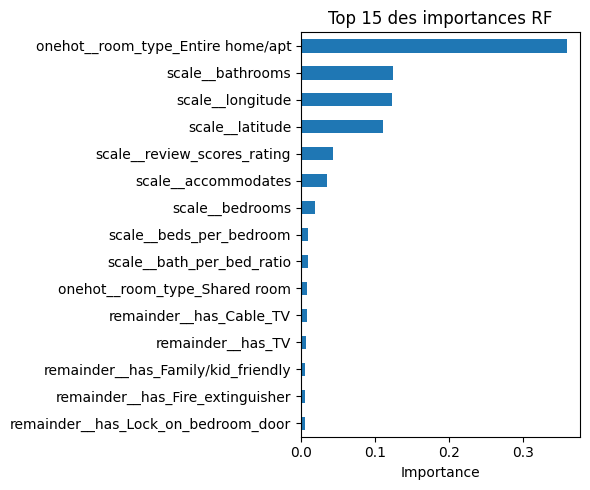

In [135]:
# Récupérer noms de features après transformation
feat_names = best_model.named_steps['prep'].get_feature_names_out()

# Extraire importances du RandomForest
importances = best_model.named_steps['rf'].feature_importances_

# Construire une Series et afficher top 15
import pandas as pd
imp_series = pd.Series(importances, index=feat_names)
top15      = imp_series.sort_values(ascending=False).head(15)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
top15.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 des importances RF")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [136]:
print("Total features utilisées :", len(feat_names))
for f in feat_names:
    print("-", f)


Total features utilisées : 77
- scale__accommodates
- scale__bedrooms
- scale__beds
- scale__bathrooms
- scale__review_scores_rating
- scale__beds_per_bedroom
- scale__bath_per_bed_ratio
- scale__latitude
- scale__longitude
- onehot__city_cat_Boston
- onehot__city_cat_Chicago
- onehot__city_cat_DC
- onehot__city_cat_LA
- onehot__city_cat_NYC
- onehot__city_cat_SF
- onehot__room_type_Entire home/apt
- onehot__room_type_Private room
- onehot__room_type_Shared room
- onehot__property_type_Apartment
- onehot__property_type_Bed & Breakfast
- onehot__property_type_Boat
- onehot__property_type_Boutique hotel
- onehot__property_type_Bungalow
- onehot__property_type_Cabin
- onehot__property_type_Camper/RV
- onehot__property_type_Castle
- onehot__property_type_Chalet
- onehot__property_type_Condominium
- onehot__property_type_Dorm
- onehot__property_type_Earth House
- onehot__property_type_Guest suite
- onehot__property_type_Guesthouse
- onehot__property_type_Hostel
- onehot__property_type_House

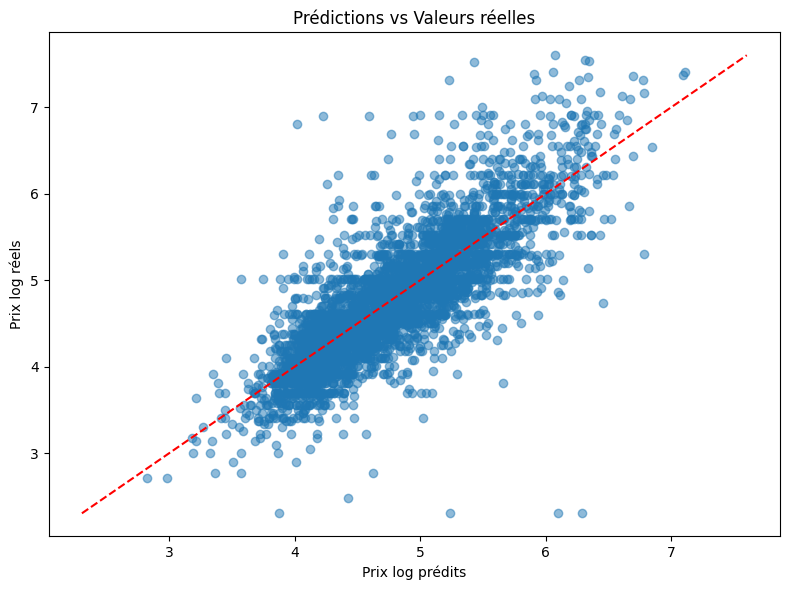

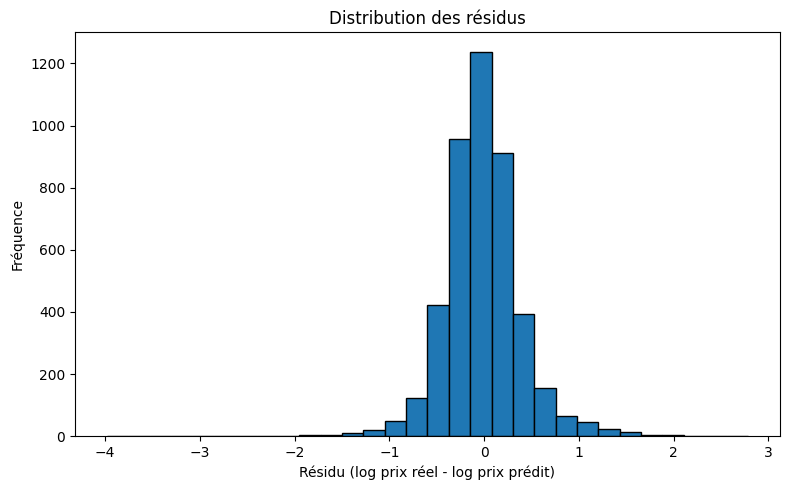

In [137]:
# Visualisations des résultats
# 1. Scatter plot: Prédictions vs Vérités
y_pred = best_model.predict(X_test)  # Utiliser best_model au lieu de model
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, y_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color='red')
plt.xlabel('Prix log prédits')
plt.ylabel('Prix log réels')
plt.title('Prédictions vs Valeurs réelles')
plt.tight_layout()
plt.show()

# 2. Histogramme des résidus
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Distribution des résidus')
plt.xlabel('Résidu (log prix réel - log prix prédit)')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

In [53]:
# Chargement des données de test
airbnb_test = pd.read_csv("airbnb_test.csv")

# 1. Préparation des données de test avec les mêmes transformations que pour l'entraînement

# Nettoyage et encodage des amenities
amen_raw_test = (
    airbnb_test['amenities']
        .fillna('[]')
        .str.replace(r'[\{\}"]', '', regex=True)
        .str.split(',')
        .apply(lambda lst: [x.strip() for x in lst if x.strip()])
)

# Encodage binaire avec les mêmes amenities que dans l'entraînement
for amen in top25:
    col = f"has_{amen.replace(' ', '_')}"
    airbnb_test[col] = amen_raw_test.apply(lambda lst: int(amen in lst))

# Catégorisation des villes rares
city_counts = data['city'].value_counts()
rare = city_counts[city_counts < 75].index
airbnb_test['city_cat'] = airbnb_test['city'].where(~airbnb_test['city'].isin(rare), 'Other')

# Création des variables dérivées (sans utiliser price)
airbnb_test['beds_per_bedroom'] = airbnb_test['beds'] / (airbnb_test['bedrooms'] + 1e-6)
airbnb_test['bath_per_bed_ratio'] = airbnb_test['bathrooms'] / (airbnb_test['beds'] + 1e-6)

# Clustering géographique
coords_test = airbnb_test[['latitude', 'longitude']].dropna()
coords_norm_test = StandardScaler().fit_transform(coords_test)
airbnb_test['geo_group'] = np.nan
airbnb_test.loc[coords_test.index, 'geo_group'] = kmeans.predict(coords_norm_test)

# 2. Extraction des features utilisées par le modèle
X_test_final = airbnb_test[num_feats + cat_feats + amen_feats]

# 3. Gestion des valeurs manquantes
for col in X_test_final.columns:
    if X_test_final[col].isna().any():
        if X_test_final[col].dtype.kind in 'fc':  # Colonnes numériques
            X_test_final[col].fillna(X_test_final[col].median(), inplace=True)
        else:  # Colonnes catégorielles
            X_test_final[col].fillna(X_test_final[col].mode().iloc[0], inplace=True)

# 4. Prédiction avec le modèle optimisé
y_final_prediction = best_model.predict(X_test_final)

# 5. Sauvegarde des prédictions dans le format attendu
prediction_example = pd.read_csv("prediction_example.csv")
prediction_example["logpred"] = y_final_prediction
prediction_example.to_csv("MaPredictionFinale.csv", index=False)

print("Prédictions sauvegardées dans 'MaPredictionFinale.csv'")

# 6. Vérification de la conformité du fichier généré
def estConforme(monFichier_csv):
    votre_prediction = pd.read_csv(monFichier_csv)
    fichier_exemple = pd.read_csv("prediction_example.csv")

    assert votre_prediction.columns[1] == fichier_exemple.columns[1], f"Attention, votre colonne de prédiction doit s'appeler {fichier_exemple.columns[1]}, elle s'appelle '{votre_prediction.columns[1]}'"
    assert len(votre_prediction) == len(fichier_exemple), f"Attention, vous devriez avoir {len(fichier_exemple)} prédiction dans votre fichier, il en contient '{len(votre_prediction)}'"
    assert np.all(votre_prediction.iloc[:,0] == fichier_exemple.iloc[:, 0])
    
    print("Fichier conforme!")

estConforme("MaPredictionFinale.csv")

C:\Users\aurel\AppData\Local\Temp\ipykernel_8892\470499520.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test_final[col].fillna(X_test_final[col].median(), inplace=True)
C:\Users\aurel\AppData\Local\Temp\ipykernel_8892\470499520.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_final[col].fillna(X_test_final[col].median(), i

Prédictions sauvegardées dans 'MaPredictionFinale.csv'
Fichier conforme!
